In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef
from sklearn.ensemble import RandomForestClassifier
import xgboost
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB

In [2]:
dataset = pd.read_csv(r"C:\Ddrive\Bits\sem1\ML\Assignment2\diabetes_012_health_indicators_BRFSS2015.csv")
X = dataset.drop('Diabetes_012', axis=1)
y = dataset['Diabetes_012']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [3]:
Xy_test = X_test.copy()
Xy_test['Diabetes_012'] = y_test
Xy_test.to_csv(r"C:\Ddrive\Bits\sem1\ML\Assignment2\Xy_test.csv", index=True)

In [4]:
Binary_cols = [col for col in dataset.columns if set(dataset[col].dropna().unique()).issubset({0.0, 1.0})]
print(Binary_cols)
print(len(Binary_cols))
non_binary_cols = [col for col in dataset.columns if col not in Binary_cols]
print(non_binary_cols)
print(len(non_binary_cols))

['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
14
['Diabetes_012', 'BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
8


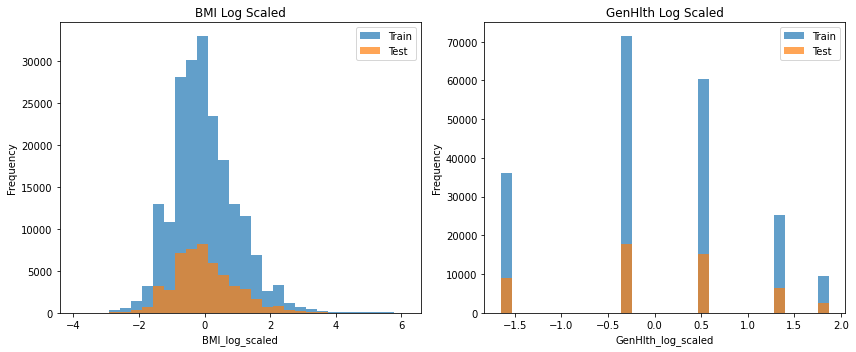

In [5]:
X_train['BMI_log'] = np.log1p(X_train['BMI'])
X_test['BMI_log'] = np.log1p(X_test['BMI'])
X_train['GenHlth_log'] = np.log1p(X_train['GenHlth'])
X_test['GenHlth_log'] = np.log1p(X_test['GenHlth'])
scaler = StandardScaler()
X_train['BMI_log_scaled'] = scaler.fit_transform(X_train[['BMI_log']])
X_test['BMI_log_scaled'] = scaler.transform(X_test[['BMI_log']])
X_train['GenHlth_log_scaled'] = scaler.fit_transform(X_train[['GenHlth_log']])
X_test['GenHlth_log_scaled'] = scaler.transform(X_test[['GenHlth_log']])
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot BMI_log_scaled
axs[0].hist(X_train['BMI_log_scaled'], bins=30, alpha=0.7, label='Train')
axs[0].hist(X_test['BMI_log_scaled'], bins=30, alpha=0.7, label='Test')
axs[0].set_title('BMI Log Scaled')
axs[0].set_xlabel('BMI_log_scaled')
axs[0].set_ylabel('Frequency')
axs[0].legend()

# Plot GenHlth_log_scaled
axs[1].hist(X_train['GenHlth_log_scaled'], bins=30, alpha=0.7, label='Train')
axs[1].hist(X_test['GenHlth_log_scaled'], bins=30, alpha=0.7, label='Test')
axs[1].set_title('GenHlth Log Scaled')
axs[1].set_xlabel('GenHlth_log_scaled')
axs[1].set_ylabel('Frequency')
axs[1].legend()

plt.tight_layout()
plt.show()


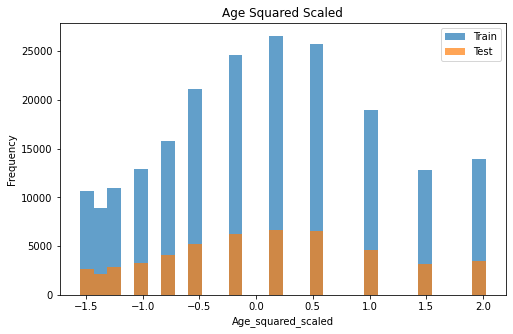

In [6]:
# Apply square transform to Age
X_train['Age_squared'] = X_train['Age'] ** 2
X_test['Age_squared'] = X_test['Age'] ** 2

# Standard scaling for Age_squared
scaler_age_sq = StandardScaler()
X_train['Age_squared_scaled'] = scaler_age_sq.fit_transform(X_train[['Age_squared']])
X_test['Age_squared_scaled'] = scaler_age_sq.transform(X_test[['Age_squared']])
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(X_train['Age_squared_scaled'], bins=30, alpha=0.7, label='Train')
ax.hist(X_test['Age_squared_scaled'], bins=30, alpha=0.7, label='Test')
ax.set_title('Age Squared Scaled')
ax.set_xlabel('Age_squared_scaled')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

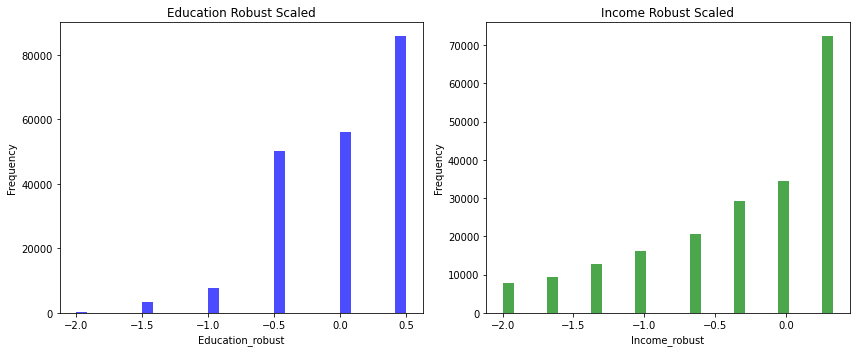

In [7]:
scaler_robust = RobustScaler()
X_train[['Education_robust', 'Income_robust']] = scaler_robust.fit_transform(X_train[['Education', 'Income']])
X_test[['Education_robust', 'Income_robust']] = scaler_robust.transform(X_test[['Education', 'Income']])

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot Education_robust
axs[0].hist(X_train['Education_robust'], bins=30, alpha=0.7, color='blue')
axs[0].set_title('Education Robust Scaled')
axs[0].set_xlabel('Education_robust')
axs[0].set_ylabel('Frequency')

# Plot Income_robust
axs[1].hist(X_train['Income_robust'], bins=30, alpha=0.7, color='green')
axs[1].set_title('Income Robust Scaled')
axs[1].set_xlabel('Income_robust')
axs[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

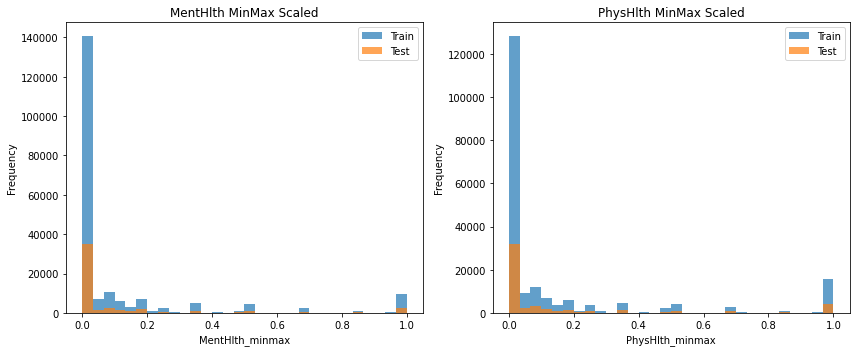

In [8]:
# Apply MinMaxScaler to MentHlth and PhysHlth
minmax_scaler = MinMaxScaler()
X_train[['MentHlth_minmax', 'PhysHlth_minmax']] = minmax_scaler.fit_transform(X_train[['MentHlth', 'PhysHlth']])
X_test[['MentHlth_minmax', 'PhysHlth_minmax']] = minmax_scaler.transform(X_test[['MentHlth', 'PhysHlth']])

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot MentHlth_minmax
axs[0].hist(X_train['MentHlth_minmax'], bins=30, alpha=0.7, label='Train')
axs[0].hist(X_test['MentHlth_minmax'], bins=30, alpha=0.7, label='Test')
axs[0].set_title('MentHlth MinMax Scaled')
axs[0].set_xlabel('MentHlth_minmax')
axs[0].set_ylabel('Frequency')
axs[0].legend()

# Plot PhysHlth_minmax
axs[1].hist(X_train['PhysHlth_minmax'], bins=30, alpha=0.7, label='Train')
axs[1].hist(X_test['PhysHlth_minmax'], bins=30, alpha=0.7, label='Test')
axs[1].set_title('PhysHlth MinMax Scaled')
axs[1].set_xlabel('PhysHlth_minmax')
axs[1].set_ylabel('Frequency')
axs[1].legend()

plt.tight_layout()
plt.show()

In [9]:
print(X_train.columns.tolist())
Trainlist = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'BMI_log_scaled', 'GenHlth_log_scaled', 'Age_squared_scaled', 'Education_robust', 'Income_robust', 'MentHlth_minmax', 'PhysHlth_minmax']

['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'BMI_log', 'GenHlth_log', 'BMI_log_scaled', 'GenHlth_log_scaled', 'Age_squared', 'Age_squared_scaled', 'Education_robust', 'Income_robust', 'MentHlth_minmax', 'PhysHlth_minmax']


In [10]:
from sklearn.linear_model import LogisticRegression

# Train logistic regression with stronger regularization and balanced class weights for highly unbalanced classes
logreg = LogisticRegression(
    max_iter=2000,           # increase max_iter for convergence
    random_state=42,
    class_weight='balanced', # handle class imbalance
    solver='saga',           # robust for large/unbalanced data
    penalty='l2',            # default regularization
    C=0.1                    # stronger regularization (smaller C)
)
logreg.fit(X_train[Trainlist], y_train)

C:\Users\pdt1cob\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=0.1, class_weight='balanced', max_iter=2000,
                   random_state=42, solver='saga')

In [11]:
# Train a decision tree classifier
dtree = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dtree.fit(X_train[Trainlist], y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    class_weight='balanced_subsample',
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train[Trainlist], y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=12,
                       min_samples_leaf=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [14]:
# Compute sample weights based on class imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

knn = KNeighborsClassifier(
    n_neighbors=11,      # you can tune this
    weights='distance',  # closer neighbors have more influence
    n_jobs=-1
)
knn.fit(X_train[Trainlist], y_train)

KNeighborsClassifier(n_jobs=-1, n_neighbors=11, weights='distance')

In [15]:
sample_weights_mnb = compute_sample_weight(class_weight='balanced', y=y_train)
mnb = GaussianNB()
mnb.fit(X_train[Trainlist], y_train, sample_weight=sample_weights_mnb)

GaussianNB()

In [20]:
y_pred_logreg = logreg.predict(X_test[Trainlist])
y_pred_dtree = dtree.predict(X_test[Trainlist])
y_pred_rf = rf.predict(X_test[Trainlist])
y_pred_knn = knn.predict(X_test[Trainlist])
y_pred_mnb = mnb.predict(X_test[Trainlist])
results = []

# Logistic Regression
results.append([
    "Logistic Regression",
    accuracy_score(y_test, y_pred_logreg),
    precision_score(y_test, y_pred_logreg, average='macro'),
    recall_score(y_test, y_pred_logreg, average='macro'),
    f1_score(y_test, y_pred_logreg, average='macro'),
    roc_auc_score(y_test, logreg.predict_proba(X_test[Trainlist]), multi_class='ovr'),
    matthews_corrcoef(y_test, y_pred_logreg)
])

# Decision Tree
results.append([
    "Decision Tree",
    accuracy_score(y_test, y_pred_dtree),
    precision_score(y_test, y_pred_dtree, average='macro'),
    recall_score(y_test, y_pred_dtree, average='macro'),
    f1_score(y_test, y_pred_dtree, average='macro'),
    roc_auc_score(y_test, dtree.predict_proba(X_test[Trainlist]), multi_class='ovr'),
    matthews_corrcoef(y_test, y_pred_dtree)
])

# Random Forest
results.append([
    "Random Forest",
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf, average='macro'),
    recall_score(y_test, y_pred_rf, average='macro'),
    f1_score(y_test, y_pred_rf, average='macro'),
    roc_auc_score(y_test, rf.predict_proba(X_test[Trainlist]), multi_class='ovr'),
    matthews_corrcoef(y_test, y_pred_rf)
])

# KNN
results.append([
    "KNN",
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn, average='macro'),
    recall_score(y_test, y_pred_knn, average='macro'),
    f1_score(y_test, y_pred_knn, average='macro'),
    roc_auc_score(y_test, knn.predict_proba(X_test[Trainlist]), multi_class='ovr'),
    matthews_corrcoef(y_test, y_pred_knn)
])

# GaussianNB
results.append([
    "GaussianNB",
    accuracy_score(y_test, y_pred_mnb),
    precision_score(y_test, y_pred_mnb, average='macro'),
    recall_score(y_test, y_pred_mnb, average='macro'),
    f1_score(y_test, y_pred_mnb, average='macro'),
    roc_auc_score(y_test, mnb.predict_proba(X_test[Trainlist]), multi_class='ovr'),
    matthews_corrcoef(y_test, y_pred_mnb)
])

# Create DataFrame
metrics = ["Model", "Accuracy", "Precision (macro)", "Recall (macro)", "F1 Score (macro)", "AUC (ovr)", "Matthews Corrcoef"]
results_df = pd.DataFrame(results, columns=metrics)
print(results_df.round(4))

                 Model  Accuracy  Precision (macro)  Recall (macro)  \
0  Logistic Regression    0.6564             0.4406          0.5243   
1        Decision Tree    0.7643             0.3903          0.3925   
2        Random Forest    0.6967             0.4317          0.5065   
3                  KNN    0.8379             0.4404          0.3911   
4           GaussianNB    0.6766             0.4229          0.4900   

   F1 Score (macro)  AUC (ovr)  Matthews Corrcoef  
0            0.4288     0.7714             0.3032  
1            0.3912     0.5588             0.1568  
2            0.4323     0.7651             0.3301  
3            0.4005     0.6963             0.2311  
4            0.4202     0.7314             0.2850  


In [21]:
joblib.dump(logreg, 'logreg_model.pkl')
joblib.dump(dtree, 'dtree_model.pkl')
joblib.dump(rf, 'rf_model.pkl')
joblib.dump(knn, 'knn_model.pkl')
joblib.dump(mnb, 'mnb_model.pkl')

['mnb_model.pkl']